# Medical Imaging Dataset Downloader (MRI + CT + X-ray)

This notebook automatically downloads multiple medical imaging datasets from Kaggle and prepares balanced samples for experimentation or machine learning.

Datasets used:
- Brain Tumor MRI Dataset
- Chest X-ray Pneumonia Dataset
- COVID-19 CT Scan Dataset

Workflow:
1. Install required libraries
2. Upload Kaggle API key
3. Download datasets using kagglehub (fast)
4. Locate images automatically
5. Create balanced samples per class
6. Display sample images


In [1]:
# Install required libraries
!pip -q install kaggle kagglehub pillow matplotlib

## Upload Kaggle API Key
Download kaggle.json from your Kaggle account settings.

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"rsanlazaro","key":"dab77f5bdc9ace1bd2456e3ca1f9270c"}'}

In [3]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

print('Kaggle API configured')

Kaggle API configured


## Download datasets

In [4]:
import kagglehub

datasets = {
    'MRI': 'masoudnickparvar/brain-tumor-mri-dataset',
    'XRAY': 'paultimothymooney/chest-xray-pneumonia',
    'CT': 'azaemon/preprocessed-ct-scans-for-covid19'
}

dataset_paths = {}

for name, ds in datasets.items():
    print(f'Downloading {name} dataset...')
    path = kagglehub.dataset_download(ds)
    dataset_paths[name] = path
    print(f'{name} dataset ready at:', path)

dataset_paths

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
MRI dataset ready at: /kaggle/input/brain-tumor-mri-dataset
Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
XRAY dataset ready at: /kaggle/input/chest-xray-pneumonia


100%|██████████| 3.59G/3.59G [00:40<00:00, 95.9MB/s]

Extracting files...


CT dataset ready at: /root/.cache/kagglehub/datasets/azaemon/preprocessed-ct-scans-for-covid19/versions/2


{'MRI': '/kaggle/input/brain-tumor-mri-dataset',
 'XRAY': '/kaggle/input/chest-xray-pneumonia',
 'CT': '/root/.cache/kagglehub/datasets/azaemon/preprocessed-ct-scans-for-covid19/versions/2'}

## Locate image files

In [5]:
import glob

image_extensions = ['*.jpg','*.jpeg','*.png']

all_images = {}

for name, path in dataset_paths.items():
    files = []
    for ext in image_extensions:
        files.extend(glob.glob(path + '/**/' + ext, recursive=True))
    all_images[name] = files
    print(name, 'images found:', len(files))

MRI images found: 7200
XRAY images found: 11712
CT images found: 39370


## Create balanced random samples

In [6]:
import random

SAMPLES_PER_DATASET = 20

samples = {}

for name, files in all_images.items():
    if len(files) < SAMPLES_PER_DATASET:
        chosen = files
    else:
        chosen = random.sample(files, SAMPLES_PER_DATASET)

    samples[name] = chosen
    print(name, 'samples selected:', len(chosen))

MRI samples selected: 20
XRAY samples selected: 20
CT samples selected: 20


## Display example images


Displaying samples from MRI


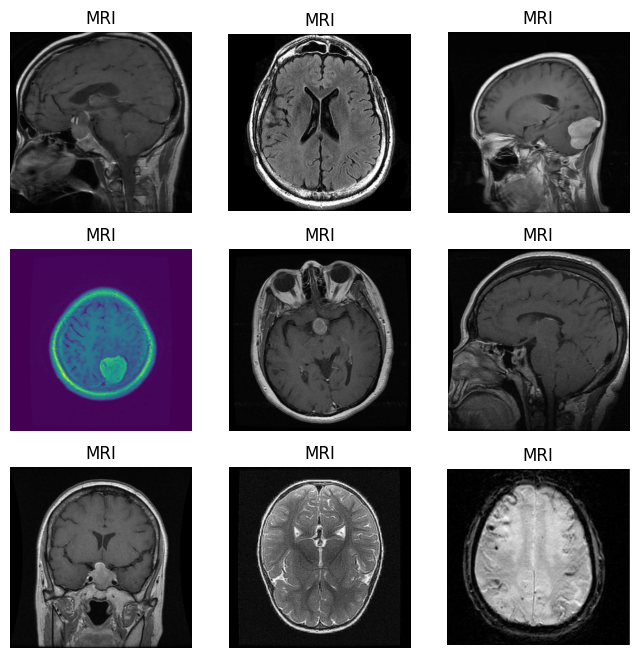


Displaying samples from XRAY


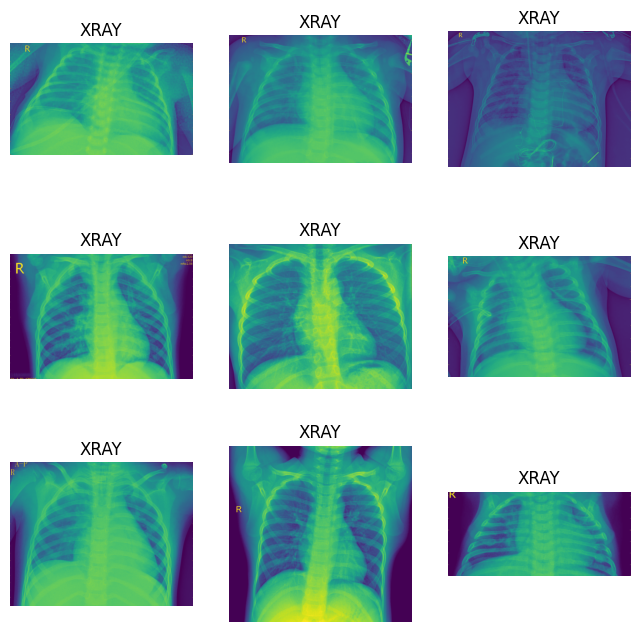


Displaying samples from CT


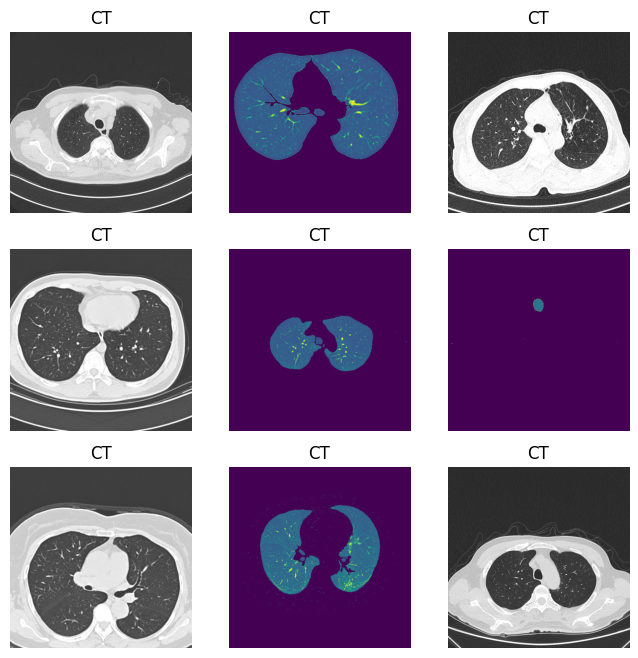

In [7]:
import matplotlib.pyplot as plt
from PIL import Image

for dataset_name, paths in samples.items():
    print('\nDisplaying samples from', dataset_name)

    plt.figure(figsize=(8,8))

    for i, p in enumerate(paths[:9]):
        img = Image.open(p)

        plt.subplot(3,3,i+1)
        plt.imshow(img)
        plt.title(dataset_name)
        plt.axis('off')

    plt.show()

## Prepare images for processing

Resize images and convert them into NumPy arrays.

In [8]:
import numpy as np
from PIL import Image

IMG_SIZE = (224,224)

X = []
y = []

for label, paths in samples.items():
    for p in paths:
        img = Image.open(p).convert('RGB')
        img = img.resize(IMG_SIZE)
        arr = np.array(img)

        X.append(arr)
        y.append(label)

X = np.array(X)
y = np.array(y)

print('Dataset prepared')
print('X shape:', X.shape)
print('y shape:', y.shape)

Dataset prepared
X shape: (60, 224, 224, 3)
y shape: (60,)
